# 1. 퍼셉트론

## 1-1. 인공신경망이란?
- **인공신경망**: 우리 뇌의 신경망(뇌를 구성하는 신경 세포끼리 서로 연결되어 정보를 처리하는 구조)을 모방한 모델
- 작용 구조
    1. 입력을 받아 가중치와 편향 적용
    2. 종합한 값을 활성화 함수에 넘김
    3. 임계값을 넘기면 유의미한 값으로 판단
    4. output 출력  
<br>
- **퍼셉트론**: 초기 형태의 인공신경망으로, 신경망(딥러닝)의 기원이 되는 선형 이진 분류기(Linear Binary Classifier)
- 출력값 구하는 과정
    1. 입력값과 가중치를 곱함
    2. 곱한 값들의 총합을 구함
    3. 총합이 임계값을 넘으면 1, 안 넘으면 0 출력 (활성화함수 step인 경우)  
<br>
- 가중치: 입력값이 출력값에 주는 영향력(중요도)
- 활성화 함수: 
    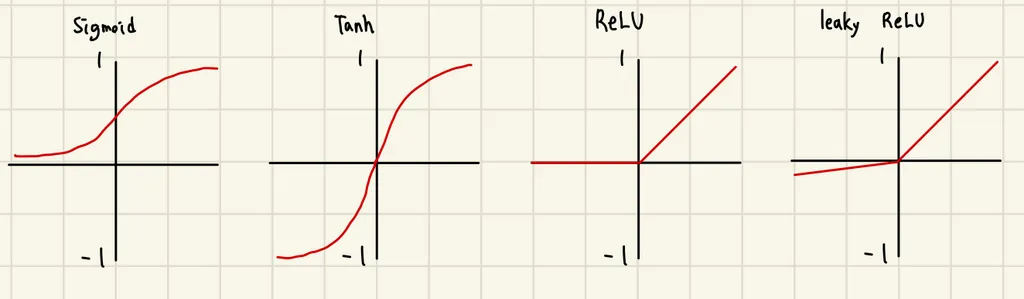
    - step: 신호가 일정 이상의 값(임계값 𝜃)을 넘으면 1, 넘지 못하면 0을 출력
    - Sigmoid
    - Tanh
    - ReLU
- 임계값: 출력을 0으로 할지 1로 할지 결정하는 기준선
- 편향: 계단 함수를 구현한 식에서, 임계값을 좌변으로 넘기면 편향(𝑏)

## 1-2. 단층 퍼셉트론과 그 한계
- **단층 퍼셉트론**: 단순히 입력층과 출력층으로만 이루어진 퍼셉트론  
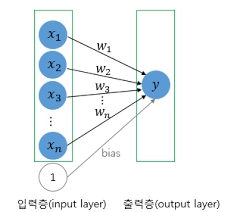  
<br>
- 논리게이트: 디지털 회로에서 기본적인 논리 연산을 수행하는 데 사용되는 구성 요소  
    1. AND 게이트: 입력값이 모두 1인 경우에만 출력값이 1이 나오는 구조
    2. OR 게이트: 입력값이 모두 0인 경우에 출력값이 0이고, 나머지 경우에는 모두 출력값이 1인 구조
    3. NAND 게이트: 입력값이 모두 1인 경우에만 출력값이 0, 나머지 경우에는 모두 출력값이 1인 구조
    4. XOR 게이트: 입력값 두 개가 서로 다른 값을 갖고 있을 때에만 출력값이 1인 구조
<br>
- 단층 퍼셉트론의 한계
    - XOR 게이트를 구현할 수 없음
    - 단층 퍼셉트론은 직선 하나로 두 영역을 나눌 수 있는 선형 분류 문제에 대해서만 구현 가능
    - XOR 게이트 =>  직선이 아닌 곡선/비선형 영역으로 분리해야만 구현 가능
    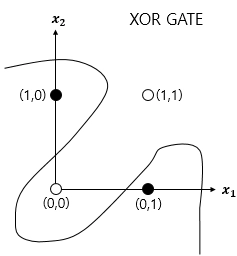

## 1-3. 다층 퍼셉트론
- **다층 퍼셉트론**: 여러 층의 단층 퍼셉트론, XOR 게이트는 기존의 AND, NAND, OR 게이트를 조합하면 만들 수 있음  
- 심층신경망: 은닉층이 2개 이상인 신경망
- 딥러닝: 심층 신경망을 학습(가중치를 스스로 찾도록) 시킴

# 2. 딥러닝 모델의 학습

## 2-1. 순전파와 역전파
- 딥러닝 학습의 전체 흐름
    1. **순전파** => 입력값이 각 층을 통과하며 예측값 도출
    2. 손실 계산 => 예측값과 실제값 비교하여 오차 계산
    3. **역전파** => 손실이 계산되면, 출력층부터 거꾸로 거슬러 올라가며 각 가중치가 손실에 얼마나 기여했는지 계산
    4. 가중치 업데이트 => 가중치를 수정하며 모델의 정확도 향상
<br>
- 딥러닝 학습 알고리즘
    1. **순전파**를 통해 입력값으로부터 예측 수행
    2. 오차 계산을 통해 예측 정확도 측정
    3. **역전파**를 통해 출력층에서 다시 입력층 방향으로 오차 전달
    4. 가중치 업데이트
    => 오차가 0에 가까워지도록 반복
<br>
- **연쇄 법칙**: 합성함수의 미분은 각 함수의 미분의 곱으로 나타낼 수 있다는 법칙
    - 역전파 과정에서 각 가중치가 최종 손실에 얼마나 기여했는지를 계산 => 연쇄법칙 사용
    - 연쇄법칙을 통해 구하는 기울기 = ‘손실 함수를 줄이기 위해 가중치를 어떻게 바꿀까?’를 알려주는 신호
<br>
- 기울기 소실 문제: 각 단계마다 미분값이 1보다 작은 값이라면 기울기가 0에 수렴하는 문제 발생
    - 앞쪽 층의 가중치가 거의 업데이트되지 않아서 학습이 제대로 이뤄지지 않는 문제가 생김

## 2-2. 손실함수
- **손실함수**: 모델의 예측이 얼마나 틀렸는지를 수치로 표현하는 방법
    - 실제값(정답)과 예측값(출력값)의 차이를 계산하는 데에 사용되는 함수

- 손실함수의 종류:
    - **평균 제곱 오차 (MSE)**: 예측 값이 연속적이고, 예측 값과 실제 값 간의 차이를 직접적으로 측정하는 회귀 문제에 적합
    - **이진 크로스 엔트로피(Binary Cross-Entropy Loss, BCE)**: 이진 분류 문제(로지스틱 회귀)에서 사용하는 손실 함수  
    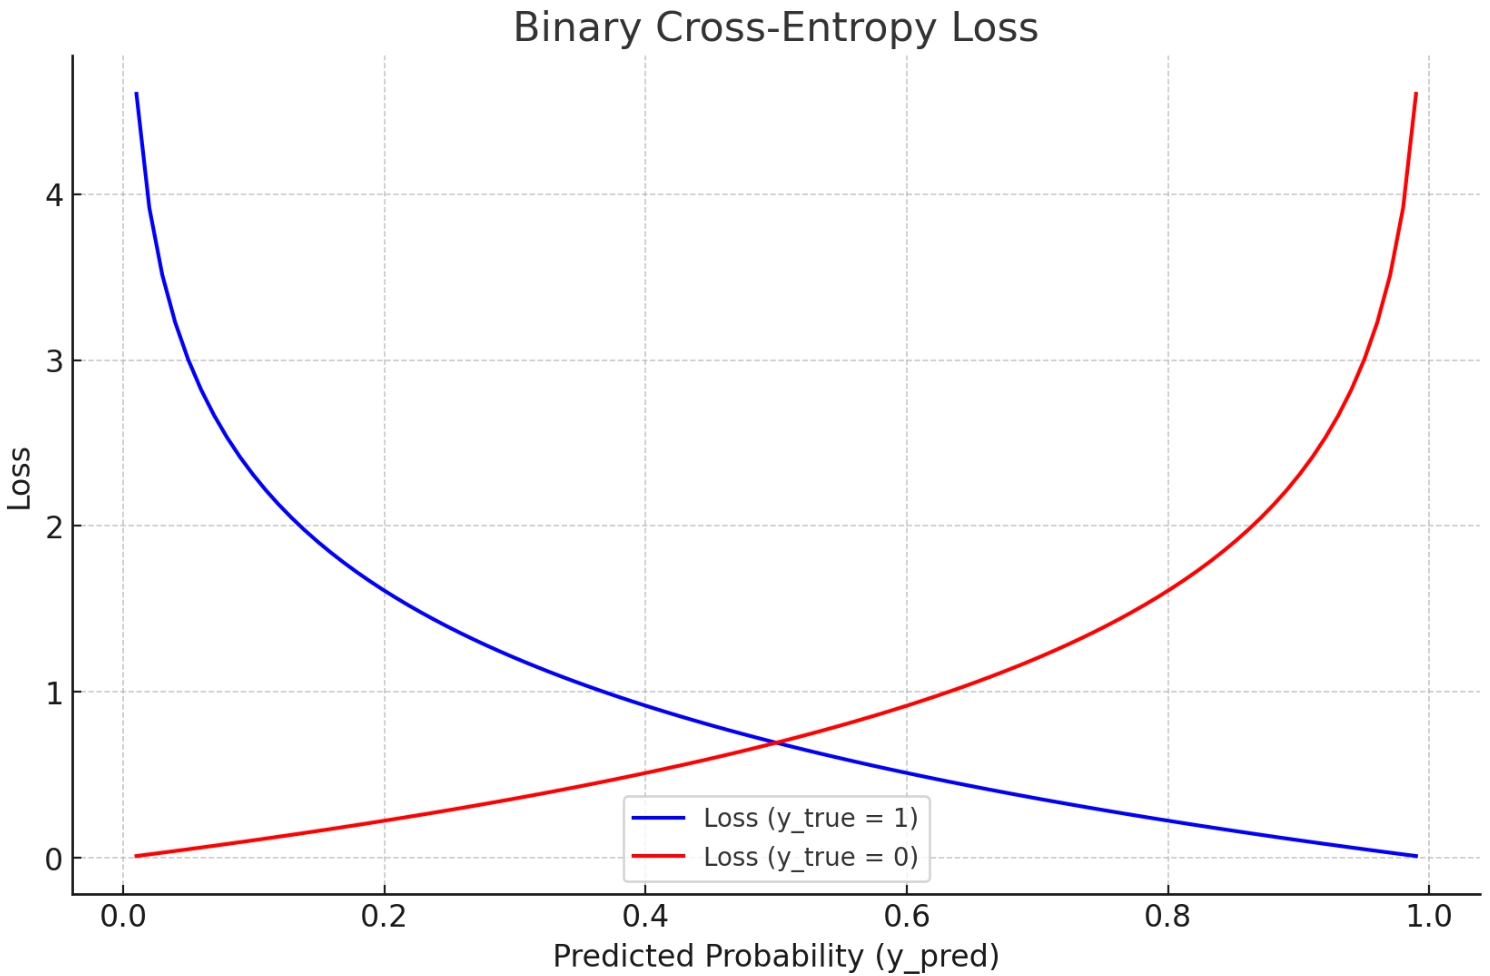  
    - **크로스 엔트로피 오차(Cross Entropy Error, CEE)**: 다중 클래스 분류 문제에서 예측 확률이 실제 클래스와 얼마나 일치하는 지를 평가하는 데 적합, 다중 분류에서 사용


## 2-3. 활성화 함수
- **활성화 함수**: 각 층의 출력값에 **비선형성**을 추가해서 신경망이 복잡한 패턴도 학습할 수 있게 해주는 함수  
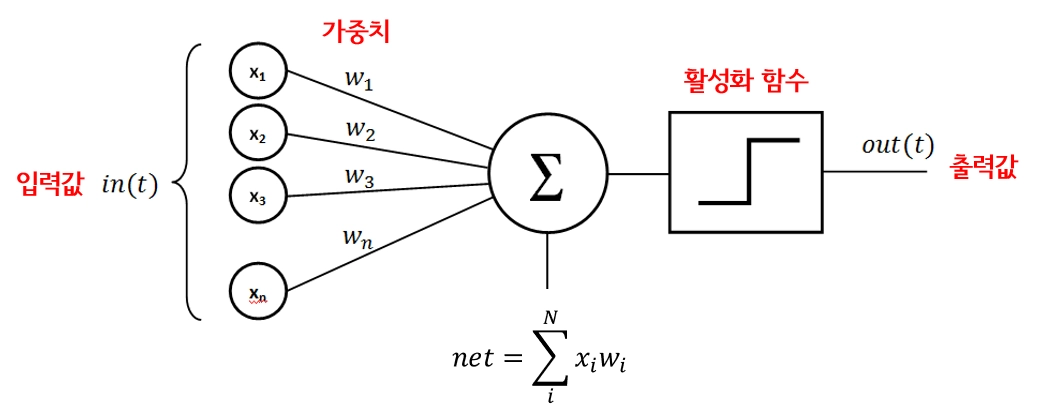  
	
| 구분 | 단층 퍼셉트론 | 다층 퍼셉트론 |
|------|---------------|---------------|
| 활성화 함수 | 계단 함수 | Sigmoid, ReLU 등 |
| 출력값 | 0 또는 1 (이진 출력) | 연속적인 값 (확률 또는 실수) |
| 특징 | 선형 문제만 풀 수 있음 | 복잡한 비선형 문제도 학습 가능 |   
<br>
- **계단함수**: 입력값과 가중치의 곱을 모두 더한 뒤, 그 합이 특정 기준(임계값)을 넘으면 1, 아니면 0을 출력하는 함수  
<br>
- **시그모이드 함수**: 입력 신호를 0과 1 사이의 연속적인 값으로 변환하는 비선형 함수
    - 계단 함수는 0 또는 1만 출력하는 반면, 시그모이드 함수는 x값에 따라 출력값이 연속적으로 변화  
<br>
- **ReLU 함수**: 입력이 0보다 크면 그대로, 0 이하면 0을 출력하는 비선형 함수  
    - 계산이 간단하고 효율적
    - 비선형성 제공
    - 기울기 소실 문제 완화 
    => 딥러닝에서 가장 많이 이용  
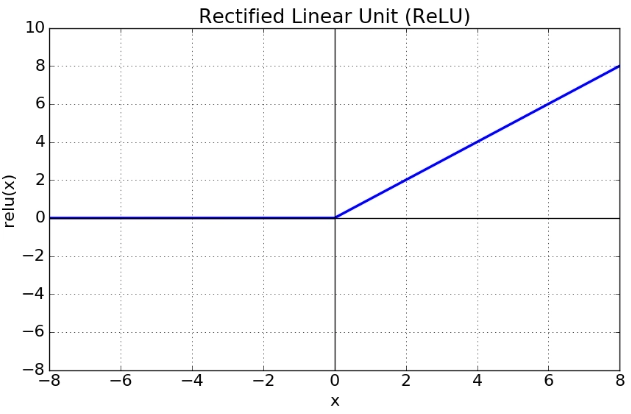  
<br>
- **Tanh(쌍곡탄젠트) 함수**: 시그모이드 함수의 변형으로, 출력값의 범위가 -1 ~ 1  
    - 입력값의 중심을 0으로 맞추고 싶을 때 사용 => 중심이 0이면 학습 과정에서 가중치 업데이트가 더 안정적으로 이루어짐   
<br>
- **softmax 함수**: 각 클래스에 대한 출력값을 확률로 변환하는 함수  
    - 다중 클래스 분류 문제의 출력층에서 사용
    - 각 클래스에 속할 확률을 직접 읽을 수 있음  
<br>

| 활성화함수 | 출력 범위 | 주요 사용처 | 장점 | 단점 |
|------------|-----------|-------------|------|------|
| 계단 함수 | 0 또는 1 | 단층 퍼셉트론 | 구조가 단순 | 미분 불가 |
| Sigmoid | 0 ~ 1 | 이진 분류 출력층 | 확률로 해석 가능 | 기울기 소실 문제 |
| Tanh | -1 ~ 1 | 은닉층 | 출력 중심이 0으로 학습 안정적 | 기울기 소실 문제 |
| ReLU | 0 ~ ∞ | 은닉층 전반 | 계산 빠름, 기울기 소실 완화 | 음수 입력 시 출력이 항상 0 |
| Softmax | 0 ~ 1 (합=1) | 다중 분류 출력층 | 클래스별 확률 직접 출력 | 출력층 전용, 은닉층엔 부적합 |  


## 2-4. 경사하강법
-**경사하강법**: 손실 함수를 최소화하여 모델을 학습시키는 방법 => 오차를 가장 작게 만드는 가중치와 편향을 찾는 방법
<br>
- 배치: 학습 과정에서 가중치와 같은 매개변수를 조정하기 위해 사용하는 데이터의 묶음을 의미
    - 사용자가 임의로 정할 수 있는 하이퍼파라미터
    - 배치 크기가 너무 큰 경우, 학습이 느려지고 메모리가 부족해질 수 있음
    - 배치 크기가 너무 작으면, 가중치가 자주 업데이트 되다 보니 학습이 불안정해질 수 있음  
    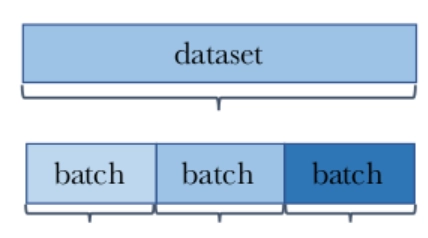  
<br>
- 에포크: 모든 데이터셋을 학습하는 횟수
- 이터레이션/스텝: 한 번의 에포크를 끝내기 위해서 필요한 배치의 수
    - 1 Epoch에서 다루는 데이터의 수 = 배치의 크기 * 이터레이션(step)
<br>
- 경사하강법 종류
    1. 배치 경사하강법: 오차를 구할 때 전체 데이터를 한 묶음으로 묶음
        - 전체 데이터를 통해 학습시키기 때문에, 업데이트 횟수가 적음
        - 메모리가 많이 필요
        - 항상 같은 데이터에 대해서 경사를 구하기 때문에 수렴이 안정적  

    2. 배치 크기가 1인 확률적 경사하강법: 매개변수 값을 조정할 때 전체 데이터가 아니라, 랜덤으로 선택된 하나의 데이터에 대해서만 계산
        - 자원이 적은 컴퓨터에서도 쉽게 사용이 가능
        - 매개변수의 변경폭이 불안정하고, 정확도가 낮을 수 있음  

    3. 미니 배치 경사하강법: 배치 크기를 적절히 지정하여 해당 데이터 개수만큼에 대해 매개 변수의 값을 조정
        - 전체 데이터를 계산하는 것보다는 빠르고, 배치 크기가 1인 경사 하강법보다 안정적 => 가장 많이 사용
        - 배치 크기는 일반적으로 2의 제곱수에 해당하는 숫자로 선택


## 2-5. 옵티마이저
- 옵티마이저: 경사하강법을 더 효율적이고 안정적으로 수행하기 위해서 필요
<br>
- **모멘텀**: 경사하강법에서 계산된 접선의 기울기에 바로 한 시점 전의 접선의 기울기값을 일정 비율만큼 반영  
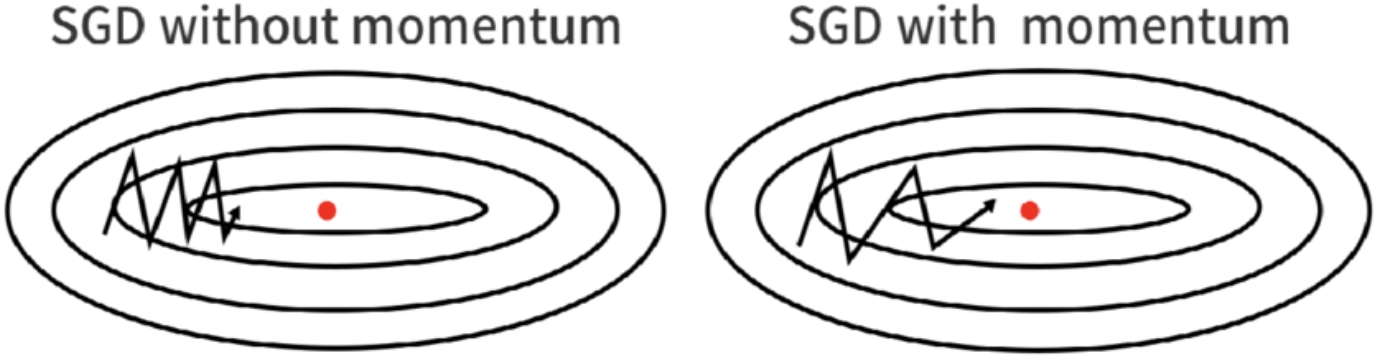  
<br>
- **알엠에스프롭(RMSProp)**: 최근 기울기를 반영하여 학습률을 조정 => 안정적이고 빠르게 학습  
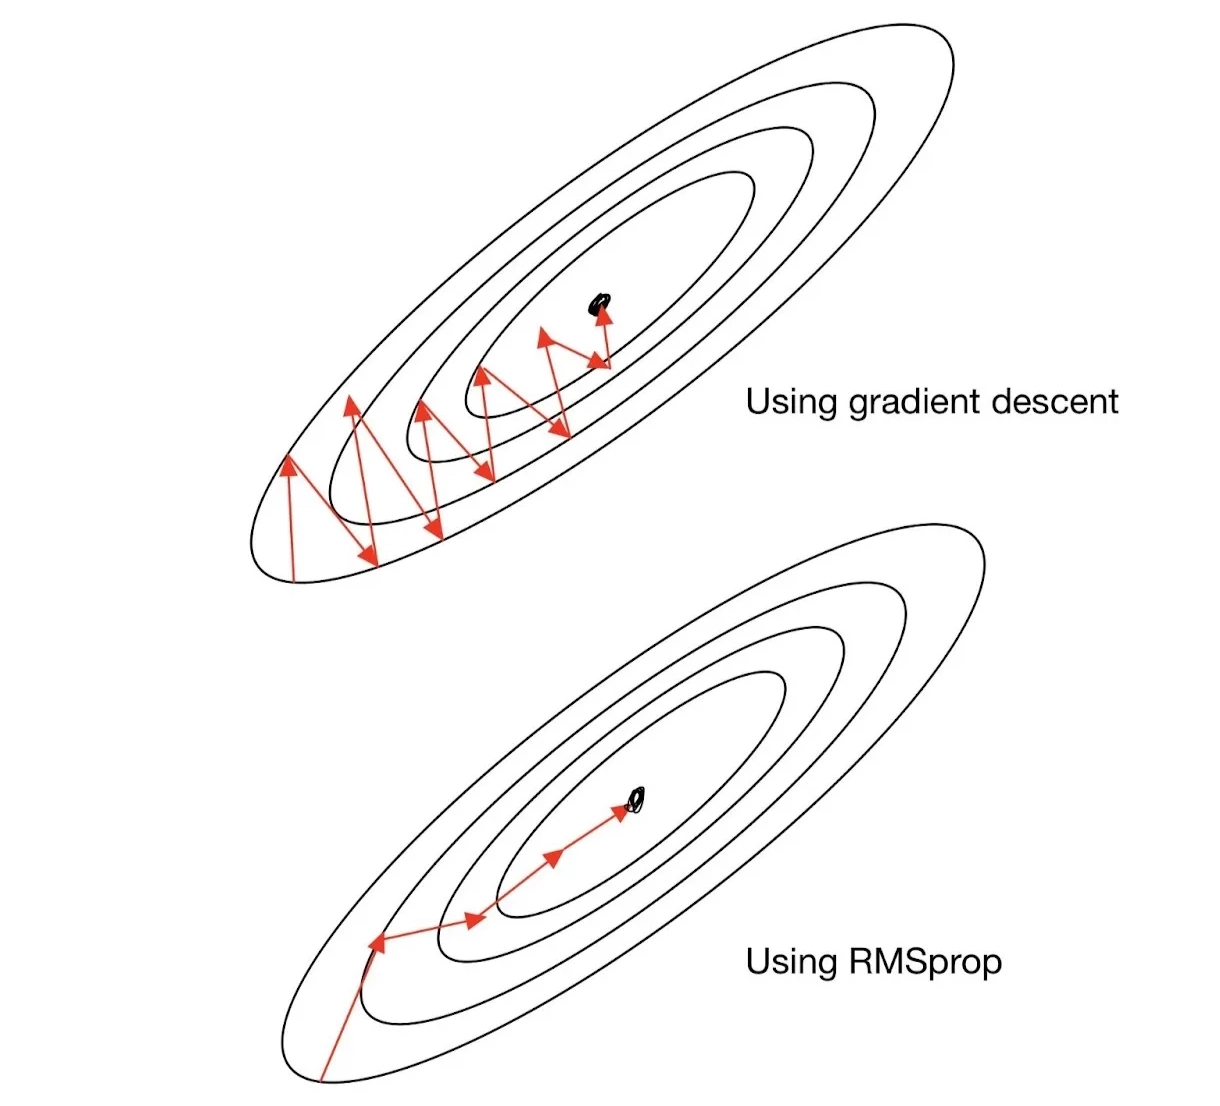  
<br>
- **아담**: RMSProp과 Momentum을 합친 방법
    - 각 파라미터의 1차 모멘트(기울기의 평균)와 2차 모멘트(기울기의 제곱 평균)을 사용하여 학습률을 조정  


## 2-6. 데이터 증강(Data Augmentation)
- 데이터 증강: 학습 데이터 셋에 일부러 다양한 변화를 가하는 것
    - 비전(이미지): 뒤집기(Flip), 회전(Rotation), 부분 자르기(Crop), 확대/축소, 밝기 조정 등
    - 자연어 처리(NLP): 동의어 대체, 랜덤 삽입/삭제, 문장 섞기, 번역 후 역번역 등
    - 데이터 증강의 장점:
        1. 모델 성능의 향상: 더욱 일반화된 패턴을 익힐 수 있음
        2. 데이터 의존성 감소
        3. 과적합 완화
        4. 데이터 프라이버시 보호